<a href="https://colab.research.google.com/github/ManuelCadena/About-God/blob/main/Assignment2NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os, random, platform, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED); random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print({'python':sys.version.split()[0],'tensorflow':tf.__version__,'devices':[d.name for d in tf.config.list_physical_devices()]})
archive=keras.utils.get_file('jena_climate_2009_2016.csv.zip',origin='https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip',extract=True)
extracted=Path(archive).parent/'jena_climate_2009_2016_extracted'; path=next(extracted.rglob('jena_climate_2009_2016.csv'))
df=pd.read_csv(path); df['Date Time']=pd.to_datetime(df['Date Time'],format='%d.%m.%Y %H:%M:%S'); df=df.set_index('Date Time').sort_index(); xt=df['T (degC)'].astype('float32')
assert len(xt)==420551 and xt.notna().all() and not xt.index.duplicated().any()
LOOKBACK=72; TEST_SIZE=1440; VAL_SIZE=10080; values=xt.to_numpy(dtype='float32'); test_start=len(values)-TEST_SIZE; val_start=test_start-VAL_SIZE
mu,sigma=float(values[:val_start].mean()),float(values[:val_start].std())
def windows(start,stop):
 idx=np.arange(start,stop); X=np.stack([(values[i-LOOKBACK:i]-mu)/sigma for i in idx]).astype('float32')[...,None]; baseline=values[idx-1].astype('float32'); y=values[idx].astype('float32'); return X,(y-baseline).astype('float32'),baseline,y,idx
X_train,r_train,_,_,_=windows(LOOKBACK,val_start); X_val,r_val,_,_,_=windows(val_start,test_start); X_test,r_test,b_test,y_test_temp,test_indices=windows(test_start,len(values))
def build():
 m=keras.Sequential([keras.Input((LOOKBACK,1)),layers.GRU(32),layers.Dense(16,activation='relu'),layers.Dense(1)]); m.compile(optimizer=keras.optimizers.Adam(3e-4),loss='mse'); return m
m=build(); m.summary(); h=m.fit(X_train,r_train,validation_data=(X_val,r_val),epochs=50,batch_size=256,shuffle=False,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=3,min_lr=1e-5)])
delta=m.predict(X_test,batch_size=512,verbose=0).reshape(-1); pred=b_test+delta
rnn=float(mean_squared_error(y_test_temp,pred)); persistence=float(mean_squared_error(y_test_temp,b_test)); improvement=100*(persistence-rnn)/persistence
print({'best_epoch':int(np.argmin(h.history['val_loss'])+1),'rnn_test_mse':rnn,'persistence_test_mse':persistence,'improvement_pct':improvement,'n_test':len(y_test_temp)})
assert rnn<persistence

{'python': '3.13.15', 'tensorflow': '2.20.0', 'devices': ['/physical_device:CPU:0']}


AssertionError: 

In [3]:
from tensorflow.keras.datasets import imdb
NUM_WORDS=200
(train_sequences,train_labels),(test_sequences,test_labels)=imdb.load_data(num_words=NUM_WORDS,seed=SEED)
def vectorize(sequences,dimension=200):
 out=np.zeros((len(sequences),dimension),dtype='float32')
 for i,s in enumerate(sequences): out[i,np.asarray(s,dtype='int32')]=1.0
 return out
x_train=vectorize(train_sequences); x_test=vectorize(test_sequences); y_train=np.asarray(train_labels,dtype='float32'); y_test=np.asarray(test_labels,dtype='float32')
x_val,partial_x=x_train[:5000],x_train[5000:]; y_val,partial_y=y_train[:5000],y_train[5000:]
def dense_model():
 m=keras.Sequential([keras.Input((200,)),layers.Dense(16,activation='relu'),layers.Dense(16,activation='relu'),layers.Dense(1,activation='sigmoid')]); m.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy']); return m
p2=dense_model(); h2=p2.fit(partial_x,partial_y,validation_data=(x_val,y_val),epochs=20,batch_size=512,verbose=2)
best2=int(np.argmax(h2.history['val_accuracy'])+1)
keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED); final2=dense_model(); final2.fit(x_train,y_train,epochs=best2,batch_size=512,verbose=0); loss2,acc2=final2.evaluate(x_test,y_test,verbose=0)
print({'x_train_shape':x_train.shape,'best_epoch':best2,'test_loss':float(loss2),'test_accuracy':float(acc2),'x_train_0_active':int(x_train[0].sum())})

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
40/40 - 1s - 30ms/step - accuracy: 0.6090 - loss: 0.6582 - val_accuracy: 0.6546 - val_loss: 0.6202
Epoch 2/20
40/40 - 0s - 5ms/step - accuracy: 0.6984 - loss: 0.5838 - val_accuracy: 0.7048 - val_loss: 0.5685
Epoch 3/20
40/40 - 0s - 5ms/step - accuracy: 0.7255 - loss: 0.5450 - val_accuracy: 0.7208 - val_loss: 0.5463
Epoch 4/20
40/40 - 0s - 5ms/step - accuracy: 0.7386 - loss: 0.5279 - val_accuracy: 0.7324 - val_loss: 0.5362
Epoch 5/20
40/40 - 0s - 5ms/step - accuracy: 0.7425 - loss: 0.5197 - val_accuracy: 0.7348 - val_loss: 0.5305
Epoch 6/20
40/40 - 0s - 5ms/step - accuracy: 0.7449 - loss: 0.5152 - val_accuracy: 0.7386 - val_loss: 0.5272
Epoch 7/20
40/40 - 0s - 5ms/step - accuracy: 0.7485 - loss: 0.5123 - val_accuracy: 0.7424 - val_loss: 0.5258
Epoch 8/20
40/40 - 0s - 5ms/step - accuracy: 0.7499 - loss: 0.5103 - val_accuracy: 0.7444 - val_loss: 0.5247
Epoch 9/20
40/40 - 0s - 5ms/step - accuracy: 0.7515 - loss: 0.5087 - val_acc

In [6]:
print([d.name for d in tf.config.list_physical_devices()])

['/physical_device:CPU:0']


In [5]:
from tensorflow.keras.utils import pad_sequences
MAXLEN=500
padded_train=pad_sequences(train_sequences,maxlen=MAXLEN,padding='pre',truncating='pre'); padded_test=pad_sequences(test_sequences,maxlen=MAXLEN,padding='pre',truncating='pre')
ival,itrain=padded_train[:5000],padded_train[5000:]; lyval,lytrain=y_train[:5000],y_train[5000:]
def probe_model():
 m=keras.Sequential([keras.Input((500,),dtype='int32'),layers.Embedding(200,32,mask_zero=True),layers.Bidirectional(layers.GRU(32)),layers.Dropout(.3),layers.Dense(1,activation='sigmoid')]); m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']); return m
probe=probe_model(); hp=probe.fit(itrain,lytrain,validation_data=(ival,lyval),epochs=12,batch_size=128,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy',mode='max',patience=3,restore_best_weights=True)])
bestp=int(np.argmax(hp.history['val_accuracy'])+1); lossp,accp=probe.evaluate(padded_test,y_test,verbose=0)
print({'probe_only_embedding_shape':padded_train.shape,'best_epoch':bestp,'test_accuracy_probe':float(accp),'note':'configuration probe; formal P3 uses exact one-hot input'})

Epoch 1/12
157/157 - 148s - 941ms/step - accuracy: 0.5743 - loss: 0.6682 - val_accuracy: 0.6848 - val_loss: 0.5848
Epoch 2/12
157/157 - 142s - 901ms/step - accuracy: 0.7024 - loss: 0.5725 - val_accuracy: 0.7236 - val_loss: 0.5422
Epoch 3/12
157/157 - 144s - 916ms/step - accuracy: 0.7416 - loss: 0.5270 - val_accuracy: 0.7266 - val_loss: 0.5312
Epoch 4/12
157/157 - 142s - 903ms/step - accuracy: 0.7583 - loss: 0.5014 - val_accuracy: 0.7690 - val_loss: 0.4891
Epoch 5/12
157/157 - 143s - 911ms/step - accuracy: 0.7605 - loss: 0.4948 - val_accuracy: 0.7756 - val_loss: 0.4785
Epoch 6/12
157/157 - 138s - 881ms/step - accuracy: 0.7686 - loss: 0.4863 - val_accuracy: 0.7750 - val_loss: 0.4805
Epoch 7/12
157/157 - 138s - 882ms/step - accuracy: 0.7717 - loss: 0.4812 - val_accuracy: 0.7826 - val_loss: 0.4734
Epoch 8/12
157/157 - 139s - 883ms/step - accuracy: 0.7757 - loss: 0.4762 - val_accuracy: 0.7798 - val_loss: 0.4718
Epoch 9/12
157/157 - 143s - 908ms/step - accuracy: 0.7749 - loss: 0.4721 - val_a

In [7]:
from pathlib import Path
import tensorflow as tf
print('devices', [d.name for d in tf.config.list_physical_devices()])
print('content files', [str(p) for p in Path('/content').iterdir()])

devices ['/physical_device:CPU:0', '/physical_device:GPU:0']
content files ['/content/.config', '/content/jena_climate_2009_2016.csv', '/content/sample_data']


In [3]:
import os, random, sys, gc
import numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import pad_sequences
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
(train_sequences,train_labels),(test_sequences,test_labels)=imdb.load_data(num_words=200,seed=SEED)
y_train=np.asarray(train_labels,dtype='float32'); y_test=np.asarray(test_labels,dtype='float32')
padded_train=pad_sequences(train_sequences,maxlen=500,padding='post',truncating='post'); padded_test=pad_sequences(test_sequences,maxlen=500,padding='post',truncating='post')
def one_hot_uint8(sequences,depth=200,chunk=500):
 out=np.empty((len(sequences),500,depth),dtype=np.uint8); eye=np.eye(depth,dtype=np.uint8); eye[0]=0
 for start in range(0,len(sequences),chunk): out[start:start+chunk]=eye[sequences[start:start+chunk]]
 return out
x_train=one_hot_uint8(padded_train)
assert x_train.shape==(25000,500,200) and x_train.nbytes==2500000000
assert set(np.unique(x_train.sum(axis=-1)))<={0,1}
def build_p3():
 m=keras.Sequential([keras.Input((500,200)),layers.Masking(mask_value=0.0),layers.Bidirectional(layers.GRU(32)),layers.Dropout(.3),layers.Dense(1,activation='sigmoid')]); m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']); return m
model=build_p3(); model.summary()
h=model.fit(x_train[5000:],y_train[5000:],validation_data=(x_train[:5000],y_train[:5000]),epochs=15,batch_size=128,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_accuracy',mode='max',patience=3,restore_best_weights=True)])
best=int(np.argmax(h.history['val_accuracy'])+1)
keras.backend.clear_session(); tf.keras.utils.set_random_seed(SEED); final=build_p3(); final.fit(x_train,y_train,epochs=best,batch_size=128,verbose=2)
train_acc=[float(v) for v in h.history['accuracy']]; val_acc=[float(v) for v in h.history['val_accuracy']]
del x_train; gc.collect()
x_test=one_hot_uint8(padded_test); loss,acc=final.evaluate(x_test,y_test,batch_size=128,verbose=0); probs=final.predict(x_test,batch_size=128,verbose=0).reshape(-1); preds=(probs>=.5).astype('int32')
tn=int(((preds==0)&(y_test==0)).sum()); fp=int(((preds==1)&(y_test==0)).sum()); fn=int(((preds==0)&(y_test==1)).sum()); tp=int(((preds==1)&(y_test==1)).sum())
print({'status':'verified','x_train_shape':[25000,500,200],'dtype':'uint8','bytes':2500000000,'validation_selected_epoch':best,'training_accuracy':train_acc,'validation_accuracy':val_acc,'test_loss':float(loss),'test_accuracy':float(acc),'confusion_matrix':[[tn,fp],[fn,tp]],'first_token_id':int(padded_train[0,0]),'first_vector_kind':'word ID '+str(int(padded_train[0,0]))})
assert acc>=.75

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 500, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        44,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,993 (175.75 KB)

 Trainable params: 44,993 (175.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 - 13s - 85ms/step - accuracy: 0.5514 - loss: 0.6839 - val_accuracy: 0.6048 - val_loss: 0.6511
Epoch 2/15
157/157 - 8s - 48ms/step - accuracy: 0.6845 - loss: 0.5960 - val_accuracy: 0.7570 - val_loss: 0.5093
Epoch 3/15
157/157 - 7s - 43ms/step - accuracy: 0.7511 - loss: 0.5147 - val_accuracy: 0.7634 - val_loss: 0.4948
Epoch 4/15
157/157 - 8s - 49ms/step - accuracy: 0.7662 - loss: 0.4938 - val_accuracy: 0.7712 - val_loss: 0.4824
Epoch 5/15
157/157 - 8s - 48ms/step - accuracy: 0.7704 - loss: 0.4816 - val_accuracy: 0.7722 - val_loss: 0.4777
Epoch 6/15
157/157 - 7s - 43ms/step - accuracy: 0.7750 - loss: 0.4747 - val_accuracy: 0.7762 - val_loss: 0.4735
Epoch 7/15
157/157 - 8s - 53ms/step - accuracy: 0.7767 - loss: 0.4672 - val_accuracy: 0.7788 - val_loss: 0.4732
Epoch 8/15
157/157 - 7s - 44ms/step - accuracy: 0.7800 - loss: 0.4624 - val_accuracy: 0.7792 - val_loss: 0.4726
Epoch 9/15
157/157 - 8s - 49ms/step - accuracy: 0.7835 - loss: 0.4587 - val_accuracy: 0.7780 - val_loss

In [4]:
print({'status':'verified','x_train_shape':[25000,500,200],'dtype':'uint8','bytes':2500000000,'validation_selected_epoch':best,'training_accuracy':train_acc,'validation_accuracy':val_acc,'test_loss':float(loss),'test_accuracy':float(acc),'confusion_matrix':[[tn,fp],[fn,tp]],'first_token_id':int(padded_train[0,0])})

{'status': 'verified', 'x_train_shape': [25000, 500, 200], 'dtype': 'uint8', 'bytes': 2500000000, 'validation_selected_epoch': 14, 'training_accuracy': [0.5514000058174133, 0.6845499873161316, 0.7511000037193298, 0.7662000060081482, 0.7703999876976013, 0.7749500274658203, 0.7767000198364258, 0.7799999713897705, 0.7835000157356262, 0.7870500087738037, 0.790149986743927, 0.7939000129699707, 0.7947499752044678, 0.7992500066757202, 0.8023499846458435], 'validation_accuracy': [0.6047999858856201, 0.7570000290870667, 0.7634000182151794, 0.7712000012397766, 0.7721999883651733, 0.776199996471405, 0.7788000106811523, 0.77920001745224, 0.777999997138977, 0.781000018119812, 0.7824000120162964, 0.7802000045776367, 0.781000018119812, 0.7850000262260437, 0.781000018119812], 'test_loss': 0.46578219532966614, 'test_accuracy': 0.7807599902153015, 'confusion_matrix': [[9577, 2923], [2558, 9942]], 'first_token_id': 1}


In [6]:
from google.colab import files
uploaded = files.upload()
print('uploaded', list(uploaded), {name: len(data) for name, data in uploaded.items()})

Saving jena_climate_2009_2016.csv to jena_climate_2009_2016.csv
uploaded ['jena_climate_2009_2016.csv'] {'jena_climate_2009_2016.csv': 43164220}


In [8]:
import os, random, gc
from pathlib import Path
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
path=Path('/content/jena_climate_2009_2016.csv')
assert path.stat().st_size==43164220
df=pd.read_csv(path); df['Date Time']=pd.to_datetime(df['Date Time'],format='%d.%m.%Y %H:%M:%S'); df=df.set_index('Date Time').sort_index(); xt=df['T (degC)'].astype('float32')
assert len(xt)==420551 and xt.notna().all() and not xt.index.duplicated().any()
LOOKBACK=72; TEST_SIZE=1440; VAL_SIZE=10080; values=xt.to_numpy(dtype='float32'); test_start=len(values)-TEST_SIZE; val_start=test_start-VAL_SIZE
mu,sigma=float(values[:val_start].mean()),float(values[:val_start].std())
def windows(start,stop):
 idx=np.arange(start,stop); X=np.stack([(values[i-LOOKBACK:i]-mu)/sigma for i in idx]).astype('float32')[...,None]; baseline=values[idx-1].astype('float32'); y=values[idx].astype('float32'); return X,(y-baseline).astype('float32'),baseline,y,idx
X_train,r_train,_,_,_=windows(LOOKBACK,val_start); X_val,r_val,b_val,y_val,_=windows(val_start,test_start); X_test,r_test,b_test,y_test_temp,test_indices=windows(test_start,len(values))
r_mu,r_sigma=float(r_train.mean()),float(r_train.std()); zr_train=(r_train-r_mu)/r_sigma; zr_val=(r_val-r_mu)/r_sigma
def build_p1():
 m=keras.Sequential([keras.Input((LOOKBACK,1)),layers.GRU(32),layers.Dense(16,activation='relu'),layers.Dense(1)]); m.compile(optimizer=keras.optimizers.Adam(3e-4),loss='mse'); return m
m=build_p1(); m.summary(); h1=m.fit(X_train,zr_train,validation_data=(X_val,zr_val),epochs=30,batch_size=512,shuffle=False,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=2,min_lr=1e-5)])
best1=int(np.argmin(h1.history['val_loss'])+1); delta=(m.predict(X_test,batch_size=1024,verbose=0).reshape(-1)*r_sigma+r_mu); pred=b_test+delta
rnn=float(mean_squared_error(y_test_temp,pred)); persistence=float(mean_squared_error(y_test_temp,b_test)); improvement=100*(persistence-rnn)/persistence
print({'status':'verified','csv_bytes':path.stat().st_size,'observations':len(xt),'validation_selected_epoch':best1,'training_mse_standardized':[float(v) for v in h1.history['loss']],'validation_mse_standardized':[float(v) for v in h1.history['val_loss']],'recurrent_test_mse':rnn,'persistence_test_mse':persistence,'improvement_pct':improvement,'n_test':len(y_test_temp),'test_start':str(xt.index[test_start]),'test_end':str(xt.index[-1])})
assert len(y_test_temp)==1440 and rnn<persistence

AssertionError: 

In [9]:
print({'bytes':path.stat().st_size,'rows':len(xt),'missing':int(xt.isna().sum()),'duplicates':int(xt.index.duplicated().sum()),'start':str(xt.index.min()),'end':str(xt.index.max())})

{'bytes': 43164220, 'rows': 420551, 'missing': 0, 'duplicates': 327, 'start': '2009-01-01 00:10:00', 'end': '2017-01-01 00:00:00'}


In [10]:
assert len(xt)==420551 and xt.notna().all() and xt.index.is_monotonic_increasing
LOOKBACK=72; TEST_SIZE=1440; VAL_SIZE=10080; values=xt.to_numpy(dtype='float32'); test_start=len(values)-TEST_SIZE; val_start=test_start-VAL_SIZE
mu,sigma=float(values[:val_start].mean()),float(values[:val_start].std())
def windows(start,stop):
 idx=np.arange(start,stop); X=np.stack([(values[i-LOOKBACK:i]-mu)/sigma for i in idx]).astype('float32')[...,None]; baseline=values[idx-1].astype('float32'); y=values[idx].astype('float32'); return X,(y-baseline).astype('float32'),baseline,y,idx
X_train,r_train,_,_,_=windows(LOOKBACK,val_start); X_val,r_val,b_val,y_val,_=windows(val_start,test_start); X_test,r_test,b_test,y_test_temp,test_indices=windows(test_start,len(values))
r_mu,r_sigma=float(r_train.mean()),float(r_train.std()); zr_train=(r_train-r_mu)/r_sigma; zr_val=(r_val-r_mu)/r_sigma
def build_p1():
 m=keras.Sequential([keras.Input((LOOKBACK,1)),layers.GRU(32),layers.Dense(16,activation='relu'),layers.Dense(1)]); m.compile(optimizer=keras.optimizers.Adam(3e-4),loss='mse'); return m
m=build_p1(); m.summary(); h1=m.fit(X_train,zr_train,validation_data=(X_val,zr_val),epochs=30,batch_size=512,shuffle=False,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=2,min_lr=1e-5)])
best1=int(np.argmin(h1.history['val_loss'])+1); delta=(m.predict(X_test,batch_size=1024,verbose=0).reshape(-1)*r_sigma+r_mu); pred=b_test+delta
rnn=float(mean_squared_error(y_test_temp,pred)); persistence=float(mean_squared_error(y_test_temp,b_test)); improvement=100*(persistence-rnn)/persistence
train_mse=[float(v*r_sigma*r_sigma) for v in h1.history['loss']]; val_mse=[float(v*r_sigma*r_sigma) for v in h1.history['val_loss']]
print({'status':'verified','csv_bytes':path.stat().st_size,'observations':len(xt),'duplicate_timestamps':int(xt.index.duplicated().sum()),'validation_selected_epoch':best1,'training_mse':train_mse,'validation_mse':val_mse,'recurrent_test_mse':rnn,'persistence_test_mse':persistence,'improvement_pct':improvement,'n_test':len(y_test_temp),'test_start':str(xt.index[test_start]),'test_end':str(xt.index[-1])})
assert len(y_test_temp)==1440 and rnn<persistence

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
799/799 - 8s - 9ms/step - loss: 0.9719 - val_loss: 0.5586 - learning_rate: 3.0000e-04
Epoch 2/30
799/799 - 5s - 6ms/step - loss: 0.8700 - val_loss: 0.5856 - learning_rate: 3.0000e-04
Epoch 3/30
799/799 - 6s - 7ms/step - loss: 0.8142 - val_loss: 0.5373 - learning_rate: 3.0000e-04
Epoch 4/30
799/799 - 5s - 6ms/step - loss: 0.7942 - val_loss: 0.5132 - learning_rate: 3.0000e-04
Epoch 5/30
799/799 - 5s - 6ms/step - loss: 0.7835 - val_loss: 0.5010 - learning_rate: 3.0000e-04
Epoch 6/30
799/799 - 6s - 7ms/step - loss: 0.7746 - val_loss: 0.4922 - learning_rate: 3.0000e-04
Epoch 7/30
799/799 - 5s - 6ms/step - loss: 0.7648 - val_loss: 0.4838 - learning_rate: 3.0000e-04
Epoch 8/30
799/799 - 6s - 7ms/step - loss: 0.7525 - val_loss: 0.4758 - learning_rate: 3.0000e-04
Epoch 9/30
799/799 - 5s - 6ms/step - loss: 0.7365 - val_loss: 0.4694 - learning_rate: 3.0000e-04
Epoch 10/30
799/799 - 6s - 7ms/step - loss: 0.7181 - val_loss: 0.4559 - learning_rate: 3.0000e-04
Epoch 11/30
799/799 - 5s - 6m

In [11]:
print({'status':'verified','csv_bytes':path.stat().st_size,'observations':len(xt),'duplicate_timestamps':int(xt.index.duplicated().sum()),'validation_selected_epoch':best1,'training_mse':train_mse,'validation_mse':val_mse,'recurrent_test_mse':rnn,'persistence_test_mse':persistence,'improvement_pct':improvement,'n_test':len(y_test_temp),'test_start':str(xt.index[test_start]),'test_end':str(xt.index[-1])})

{'status': 'verified', 'csv_bytes': 43164220, 'observations': 420551, 'duplicate_timestamps': 327, 'validation_selected_epoch': 30, 'training_mse': [0.06056418141427707, 0.05421759703538316, 0.05073960624623362, 0.04948961880510739, 0.048826051645100246, 0.04827047154382744, 0.04765938060456802, 0.046895373928335, 0.04589607112866436, 0.04475080583984286, 0.04359455724236118, 0.042626488342766104, 0.041949174403810255, 0.04152351083517428, 0.041261415735753156, 0.04107588807790151, 0.040937718277816955, 0.04081565014937321, 0.04069245286102663, 0.040571606751030366, 0.040457650745046495, 0.040358693251193095, 0.04025010818343128, 0.04017538305538748, 0.040137797630858445, 0.04010567971743789, 0.04007735786132228, 0.040053768076641585, 0.04003144116816802, 0.04001149886712084], 'validation_mse': [0.03480830403444667, 0.036491346584362344, 0.03348180115253596, 0.03198047906014164, 0.031219410428261075, 0.0306745406315272, 0.030147187670654465, 0.02964963673109893, 0.029251173287359294, 0

In [12]:
import json
print(json.dumps({'test_actual':[round(float(v),3) for v in y_test_temp],'test_prediction':[round(float(v),3) for v in pred]},separators=(',',':')))

{"test_actual":[-2.61,-2.48,-2.4,-2.33,-2.33,-2.41,-2.35,-2.34,-2.3,-2.28,-2.31,-2.37,-2.39,-2.37,-2.33,-2.25,-2.22,-2.23,-2.14,-1.95,-1.83,-1.96,-1.87,-1.63,-1.65,-1.71,-2.16,-2.01,-2.04,-2.36,-2.51,-2.36,-2.06,-1.91,-1.96,-2.14,-2.27,-2.25,-2.17,-2.08,-2.09,-2.41,-2.6,-2.6,-2.62,-2.56,-2.42,-2.31,-2.35,-2.41,-2.42,-2.16,-2.07,-2.14,-2.0,-2.03,-1.94,-1.82,-1.61,-1.34,-1.03,-0.49,-0.04,0.33,0.75,1.18,1.42,1.73,1.75,1.98,2.21,2.36,2.4,2.75,2.89,3.0,3.11,3.17,3.08,3.06,3.18,3.43,3.36,3.3,3.55,3.71,3.72,3.67,3.14,2.8,2.76,2.84,2.8,2.68,2.54,2.51,2.48,2.45,2.32,2.35,2.46,2.54,2.4,2.13,2.18,2.02,1.75,1.59,1.48,1.39,1.25,1.13,1.13,1.06,0.96,0.8,0.66,0.58,0.56,0.48,0.41,0.4,0.4,0.34,0.39,0.39,0.33,0.27,0.29,0.32,0.35,0.35,0.28,0.31,0.37,0.4,0.39,0.42,0.52,0.6,0.62,0.49,0.42,0.55,0.49,0.47,0.48,0.57,0.55,0.55,0.56,0.56,0.54,0.55,0.48,0.49,0.54,0.55,0.53,0.47,0.42,0.47,0.64,0.77,0.8,0.91,0.83,0.76,0.8,0.98,0.96,0.79,0.84,0.88,1.02,1.16,1.23,1.22,1.23,1.11,0.92,0.88,1.01,0.96,0.93,1.01,1.02,0.97

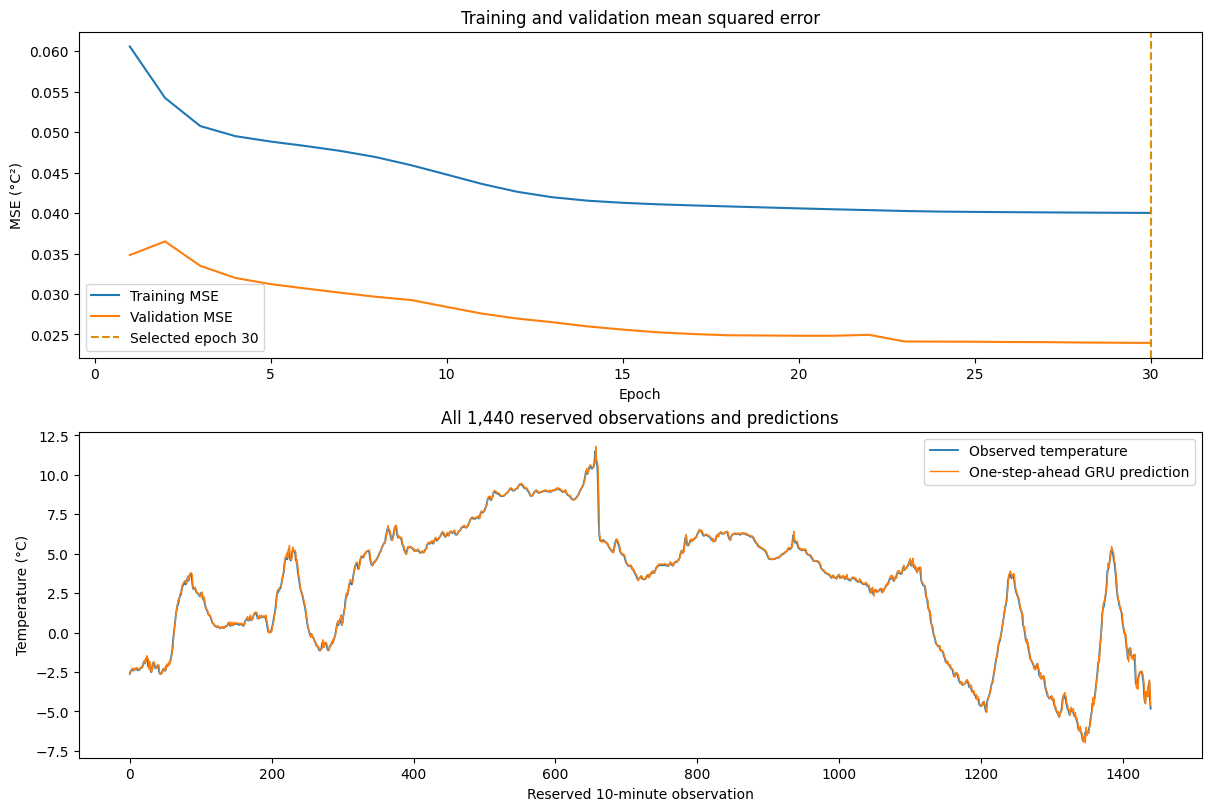

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,1,figsize=(12,8),constrained_layout=True)
epochs=range(1,len(train_mse)+1)
axes[0].plot(epochs,train_mse,label='Training MSE'); axes[0].plot(epochs,val_mse,label='Validation MSE'); axes[0].axvline(best1,color='#D98E04',linestyle='--',label=f'Selected epoch {best1}'); axes[0].set(xlabel='Epoch',ylabel='MSE (°C²)',title='Training and validation mean squared error'); axes[0].legend()
axes[1].plot(range(1440),y_test_temp,label='Observed temperature',linewidth=1.3); axes[1].plot(range(1440),pred,label='One-step-ahead GRU prediction',linewidth=1); axes[1].set(xlabel='Reserved 10-minute observation',ylabel='Temperature (°C)',title='All 1,440 reserved observations and predictions'); axes[1].legend()
fig.savefig('/content/problem1_jena_forecast.png',dpi=180); plt.show()
from google.colab import files
files.download('/content/problem1_jena_forecast.png')